# DATA CLEANING

### Import & Loading data

In [23]:
import matplotlib.pyplot as plt
print("Matplotlib OK")

Matplotlib OK


In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv(
    "data/raw/census_income_train_raw.csv",
    keep_default_na=False
)

test = pd.read_csv(
    "data/raw/census_income_test_raw.csv",
    keep_default_na=False
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (199523, 42)
Test shape: (99762, 42)


In [25]:
print("TRAIN")
display(train.head())

print("\nTEST")
display(test.head())

print("\nData types:")
print(train.dtypes)

TRAIN


,age,class_of_worker,detailed_industry_recode,detailed_occupation_recode,education,wage_per_hour,enroll_in_edu_inst_last_wk,marital_status,major_industry_code,major_occupation_code,...,country_of_birth_father,country_of_birth_mother,country_of_birth_self,citizenship,own_business_or_self_employed,fill_inc_questionnaire_for_veterans_admin,veterans_benefits,weeks_worked_in_year,year,income_class
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.



TEST


,age,class_of_worker,detailed_industry_recode,detailed_occupation_recode,education,wage_per_hour,enroll_in_edu_inst_last_wk,marital_status,major_industry_code,major_occupation_code,...,country_of_birth_father,country_of_birth_mother,country_of_birth_self,citizenship,own_business_or_self_employed,fill_inc_questionnaire_for_veterans_admin,veterans_benefits,weeks_worked_in_year,year,income_class
0,38,Private,6,36,1st 2nd 3rd or 4th grade,0,Not in universe,Married-civilian spouse present,Manufacturing-durable goods,Machine operators assmblrs & inspctrs,...,Mexico,Mexico,Mexico,Foreign born- Not a citizen of U S,0,Not in universe,2,12,95,- 50000.
1,44,Self-employed-not incorporated,37,12,Associates degree-occup /vocational,0,Not in universe,Married-civilian spouse present,Business and repair services,Professional specialty,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,26,95,- 50000.
2,2,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000.
3,35,Private,29,3,High school graduate,0,Not in universe,Divorced,Transportation,Executive admin and managerial,...,United-States,United-States,United-States,Native- Born in the United States,2,Not in universe,2,52,94,- 50000.
4,49,Private,4,34,High school graduate,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,50,95,- 50000.



Data types:
age                                            int64
class_of_worker                                  str
detailed_industry_recode                       int64
detailed_occupation_recode                     int64
education                                        str
wage_per_hour                                  int64
enroll_in_edu_inst_last_wk                       str
marital_status                                   str
major_industry_code                              str
major_occupation_code                            str
race                                             str
hispanic_origin                                  str
sex                                              str
member_of_labor_union                            str
reason_for_unemployment                          str
full_or_part_time_employment_status              str
capital_gains                                  int64
capital_losses                                 int64
dividends_from_stocks            

### Clean whitespace

In [26]:
def strip_string_columns(df):
    df = df.copy()

    string_cols = df.select_dtypes(include="object").columns

    for col in string_cols:
        df[col] = df[col].str.strip()

    return df


train_clean = strip_string_columns(train)
test_clean = strip_string_columns(test)

C:\Users\alexa\AppData\Local\Temp\ipykernel_179008\274484972.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include="object").columns
C:\Users\alexa\AppData\Local\Temp\ipykernel_179008\274484972.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guid

### Check missing "?"

In [4]:
def question_mark_summary(df):
    missing = (df == "?").sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    summary = pd.DataFrame({
        "Missing": missing,
        "Percentage": (
            missing / len(df) * 100
        ).round(2)
    })

    return summary


print("Train missing values:")
display(question_mark_summary(train_clean))

print("Test missing values:")
display(question_mark_summary(test_clean))

Train missing values:


,Missing,Percentage
migration_code_change_in_msa,99696,49.97
migration_code_change_in_region,99696,49.97
migration_code_move_within_region,99696,49.97
migration_previous_residence_in_sunbelt,99696,49.97
country_of_birth_father,6713,3.36
country_of_birth_mother,6119,3.07
country_of_birth_self,3393,1.70
state_of_previous_residence,708,0.35


Test missing values:


,Missing,Percentage
migration_code_change_in_msa,49946,50.07
migration_code_change_in_region,49946,50.07
migration_code_move_within_region,49946,50.07
migration_previous_residence_in_sunbelt,49946,50.07
country_of_birth_father,3429,3.44
country_of_birth_mother,3072,3.08
country_of_birth_self,1764,1.77
state_of_previous_residence,330,0.33


### Inspect migration missingness

In [5]:
migration_cols = [
    "migration_code_change_in_msa",
    "migration_code_change_in_region",
    "migration_code_move_within_region",
    "migration_previous_residence_in_sunbelt"
]

for col in migration_cols:
    print(f"\n{col}")
    print(train_clean[col].value_counts(dropna=False))


migration_code_change_in_msa
migration_code_change_in_msa
?                   99696
Nonmover            82538
MSA to MSA          10601
NonMSA to nonMSA     2811
Not in universe      1516
MSA to nonMSA         790
NonMSA to MSA         615
Abroad to MSA         453
Not identifiable      430
Abroad to nonMSA       73
Name: count, dtype: int64

migration_code_change_in_region
migration_code_change_in_region
?                                 99696
Nonmover                          82538
Same county                        9812
Different county same state        2797
Not in universe                    1516
Different region                   1178
Different state same division       991
Abroad                              530
Different division same region      465
Name: count, dtype: int64

migration_code_move_within_region
migration_code_move_within_region
?                               99696
Nonmover                        82538
Same county                      9812
Different county same

### Recode "?" as Unknown

In [6]:
missing_as_unknown_cols = [
    "migration_code_change_in_msa",
    "migration_code_change_in_region",
    "migration_code_move_within_region",
    "migration_previous_residence_in_sunbelt",
    "country_of_birth_father",
    "country_of_birth_mother",
    "country_of_birth_self",
    "state_of_previous_residence"
]

for col in missing_as_unknown_cols:
    train_clean[col] = train_clean[col].replace(
        "?",
        "Unknown"
    )

    test_clean[col] = test_clean[col].replace(
        "?",
        "Unknown"
    )

### Check duplicates

In [7]:
print(
    "Train duplicate rows:",
    train_clean.duplicated().sum()
)

print(
    "Test duplicate rows:",
    test_clean.duplicated().sum()
)

Train duplicate rows: 3229
Test duplicate rows: 883


### Remove exact duplicates

In [8]:
train_clean = (
    train_clean
    .drop_duplicates()
    .reset_index(drop=True)
)

test_clean = (
    test_clean
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Train after duplicate removal:", train_clean.shape)
print("Test after duplicate removal:", test_clean.shape)

Train after duplicate removal: (196294, 42)
Test after duplicate removal: (98879, 42)


### Check constant and near-constant columns

In [9]:
unique_counts = train_clean.nunique().sort_values()

print("Unique values per column:")
print(unique_counts)

Unique values per column:
sex                                              2
income_class                                     2
year                                             2
enroll_in_edu_inst_last_wk                       3
veterans_benefits                                3
fill_inc_questionnaire_for_veterans_admin        3
member_of_labor_union                            3
live_in_this_house_1_year_ago                    3
own_business_or_self_employed                    3
migration_previous_residence_in_sunbelt          4
citizenship                                      5
family_members_under_18                          5
race                                             5
region_of_previous_residence                     6
tax_filer_status                                 6
reason_for_unemployment                          6
num_persons_worked_for_employer                  7
marital_status                                   7
full_or_part_time_employment_status              8
detai

#### Constant column

In [10]:
constant_cols = unique_counts[
    unique_counts <= 1
].index.tolist()

print("Constant columns:", constant_cols)

Constant columns: []


### Inspect target

In [11]:
print(train_clean["income_class"].value_counts())

print(
    train_clean["income_class"]
    .value_counts(normalize=True)
    .round(4)
)

income_class
- 50000.    183912
50000+.      12382
Name: count, dtype: int64
income_class
- 50000.    0.9369
50000+.     0.0631
Name: proportion, dtype: float64


### Convert target to binary

In [12]:
train_clean["income_class"] = (
    train_clean["income_class"]
    .eq("50000+.")
    .astype(int)
)

test_clean["income_class"] = (
    test_clean["income_class"]
    .eq("50000+.")
    .astype(int)
)

In [13]:
print("Train target:")
print(train_clean["income_class"].value_counts())

print(
    train_clean["income_class"]
    .value_counts(normalize=True)
)

Train target:
income_class
0    183912
1     12382
Name: count, dtype: int64
income_class
0    0.936921
1    0.063079
Name: proportion, dtype: float64


### Final validation

In [14]:
print("TRAIN")
print("Shape:", train_clean.shape)
print(
    "Remaining '?' values:",
    (train_clean == "?").sum().sum()
)
print(
    "Missing pandas values:",
    train_clean.isna().sum().sum()
)

print("\nTEST")
print("Shape:", test_clean.shape)
print(
    "Remaining '?' values:",
    (test_clean == "?").sum().sum()
)
print(
    "Missing pandas values:",
    test_clean.isna().sum().sum()
)

TRAIN
Shape: (196294, 42)
Remaining '?' values: 0
Missing pandas values: 0

TEST
Shape: (98879, 42)
Remaining '?' values: 0
Missing pandas values: 0


### Check train/test consistency

In [15]:
assert list(train_clean.columns) == list(test_clean.columns)

print(
    "Train and test contain the same columns:",
    True
)

Train and test contain the same columns: True


### Save cleaned dataset

In [16]:
train_clean.to_csv(
    "census_income_train_cleaned.csv",
    index=False
)

test_clean.to_csv(
    "census_income_test_cleaned.csv",
    index=False
)

print("Saved:")
print("census_income_train_cleaned.csv")
print("census_income_test_cleaned.csv")

Saved:
census_income_train_cleaned.csv
census_income_test_cleaned.csv


# Data Exploration and Visualization

The following section is designed to satisfy the rubric requirement to report descriptive statistics, visualise **all attributes**, and investigate noisy data/outliers. The target is visualised separately from the predictor attributes.


### 1. Attribute groups and five-number summary

The five-number summary is reported for every numeric predictor. Some integer-valued fields are coded categories rather than continuous measurements, but they are retained in this table for completeness because they are stored numerically in the dataset.


In [ ]:
numeric_feature_cols = [
    col for col in train_clean.select_dtypes(include=[np.number]).columns
    if col != "income_class"
]

categorical_feature_cols = train_clean.select_dtypes(
    exclude=[np.number]
).columns.tolist()

print("Numeric predictors:", len(numeric_feature_cols))
print("Categorical predictors:", len(categorical_feature_cols))
print("Target attributes: 1")
print("Total attributes:", len(numeric_feature_cols) + len(categorical_feature_cols) + 1)

five_number_summary = (
    train_clean[numeric_feature_cols]
    .describe()
    .loc[["min", "25%", "50%", "75%", "max"]]
    .T
    .rename(columns={
        "min": "Min",
        "25%": "Q1",
        "50%": "Median",
        "75%": "Q3",
        "max": "Max"
    })
)

display(five_number_summary)


Numeric predictors: 13
Categorical predictors: 28
Target attributes: 1
Total attributes: 42


,Min,Q1,Median,Q3,Max
age,0.00,16.00,34.000,50.00,90.0
detailed_industry_recode,0.00,0.00,1.000,33.00,51.0
detailed_occupation_recode,0.00,0.00,2.000,26.00,46.0
wage_per_hour,0.00,0.00,0.000,0.00,9999.0
capital_gains,0.00,0.00,0.000,0.00,99999.0
capital_losses,0.00,0.00,0.000,0.00,4608.0
dividends_from_stocks,0.00,0.00,0.000,0.00,99999.0
instance_weight,37.87,1061.53,1620.175,2194.06,18656.3
num_persons_worked_for_employer,0.00,0.00,1.000,4.00,6.0
own_business_or_self_employed,0.00,0.00,0.000,0.00,2.0


### 2. Categorical summary

For each categorical predictor, report the number of distinct categories, the most frequent category, and its frequency. This complements the five-number summary for numeric attributes.


In [ ]:
categorical_summary = pd.DataFrame({
    "Unique categories": train_clean[categorical_feature_cols].nunique(),
    "Most frequent": [
        train_clean[col].mode().iloc[0]
        for col in categorical_feature_cols
    ],
    "Mode frequency": [
        train_clean[col].value_counts().iloc[0]
        for col in categorical_feature_cols
    ]
})

display(categorical_summary)


,Unique categories,Most frequent,Mode frequency
class_of_worker,9,Not in universe,97029
education,17,High school graduate,48374
enroll_in_edu_inst_last_wk,3,Not in universe,183762
marital_status,7,Married-civilian spouse present,84194
major_industry_code,24,Not in universe or children,97467
major_occupation_code,15,Not in universe,97467
race,5,White,164380
hispanic_origin,10,All other,168803
sex,2,Female,102400
member_of_labor_union,3,Not in universe,177232


### 3. Missing values before preprocessing

The raw training data are whitespace-normalised only for this check so explicit `?` placeholders are counted correctly.


C:\Users\alexa\AppData\Local\Temp\ipykernel_179008\274484972.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include="object").columns


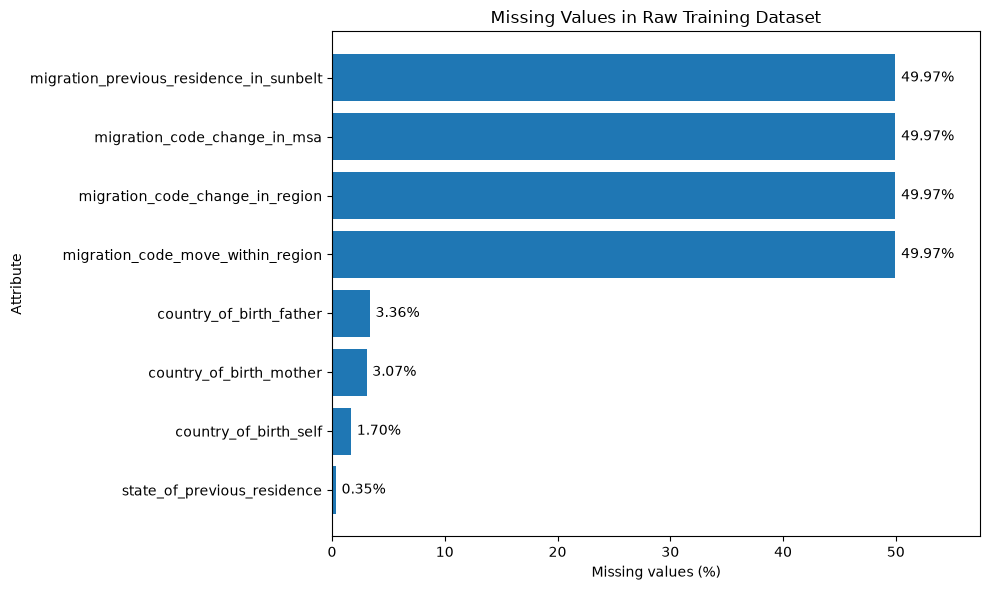

In [ ]:
train_raw_viz = strip_string_columns(train)

missing_counts = (train_raw_viz == "?").sum()
missing_counts = missing_counts[missing_counts > 0].sort_values()
missing_percent = (missing_counts / len(train_raw_viz) * 100).round(2)

plt.figure(figsize=(10, 6))
bars = plt.barh(missing_counts.index, missing_percent)

plt.xlabel("Missing values (%)")
plt.ylabel("Attribute")
plt.title("Missing Values in Raw Training Dataset")
plt.xlim(0, max(missing_percent.max() * 1.15, 1))

for bar, value in zip(bars, missing_percent):
    plt.text(
        bar.get_width() + missing_percent.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()


### 4. Target class distribution

The binary target is visualised separately to demonstrate the class imbalance after cleaning.


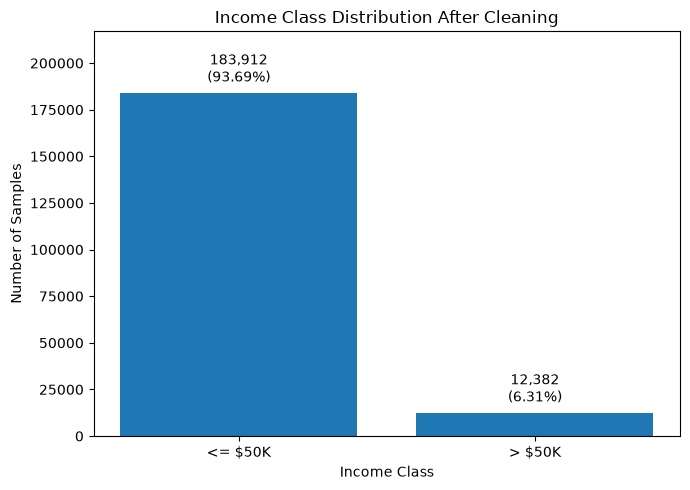

In [47]:
target_counts = train_clean["income_class"].value_counts().sort_index()
target_labels = ["<= $50K", "> $50K"]

plt.figure(figsize=(7, 5))
bars = plt.bar(target_labels, target_counts.values)

plt.xlabel("Income Class")
plt.ylabel("Number of Samples")
plt.title("Income Class Distribution After Cleaning")
plt.ylim(0, target_counts.max() * 1.18)

for bar, count in zip(bars, target_counts.values):
    percentage = count / len(train_clean) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + target_counts.max() * 0.02,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


### 5. Histograms for ALL numeric predictors

Every numeric predictor is visualised. Histograms are used to reveal skewness, zero-inflation, concentration at coded values and potential extreme observations.


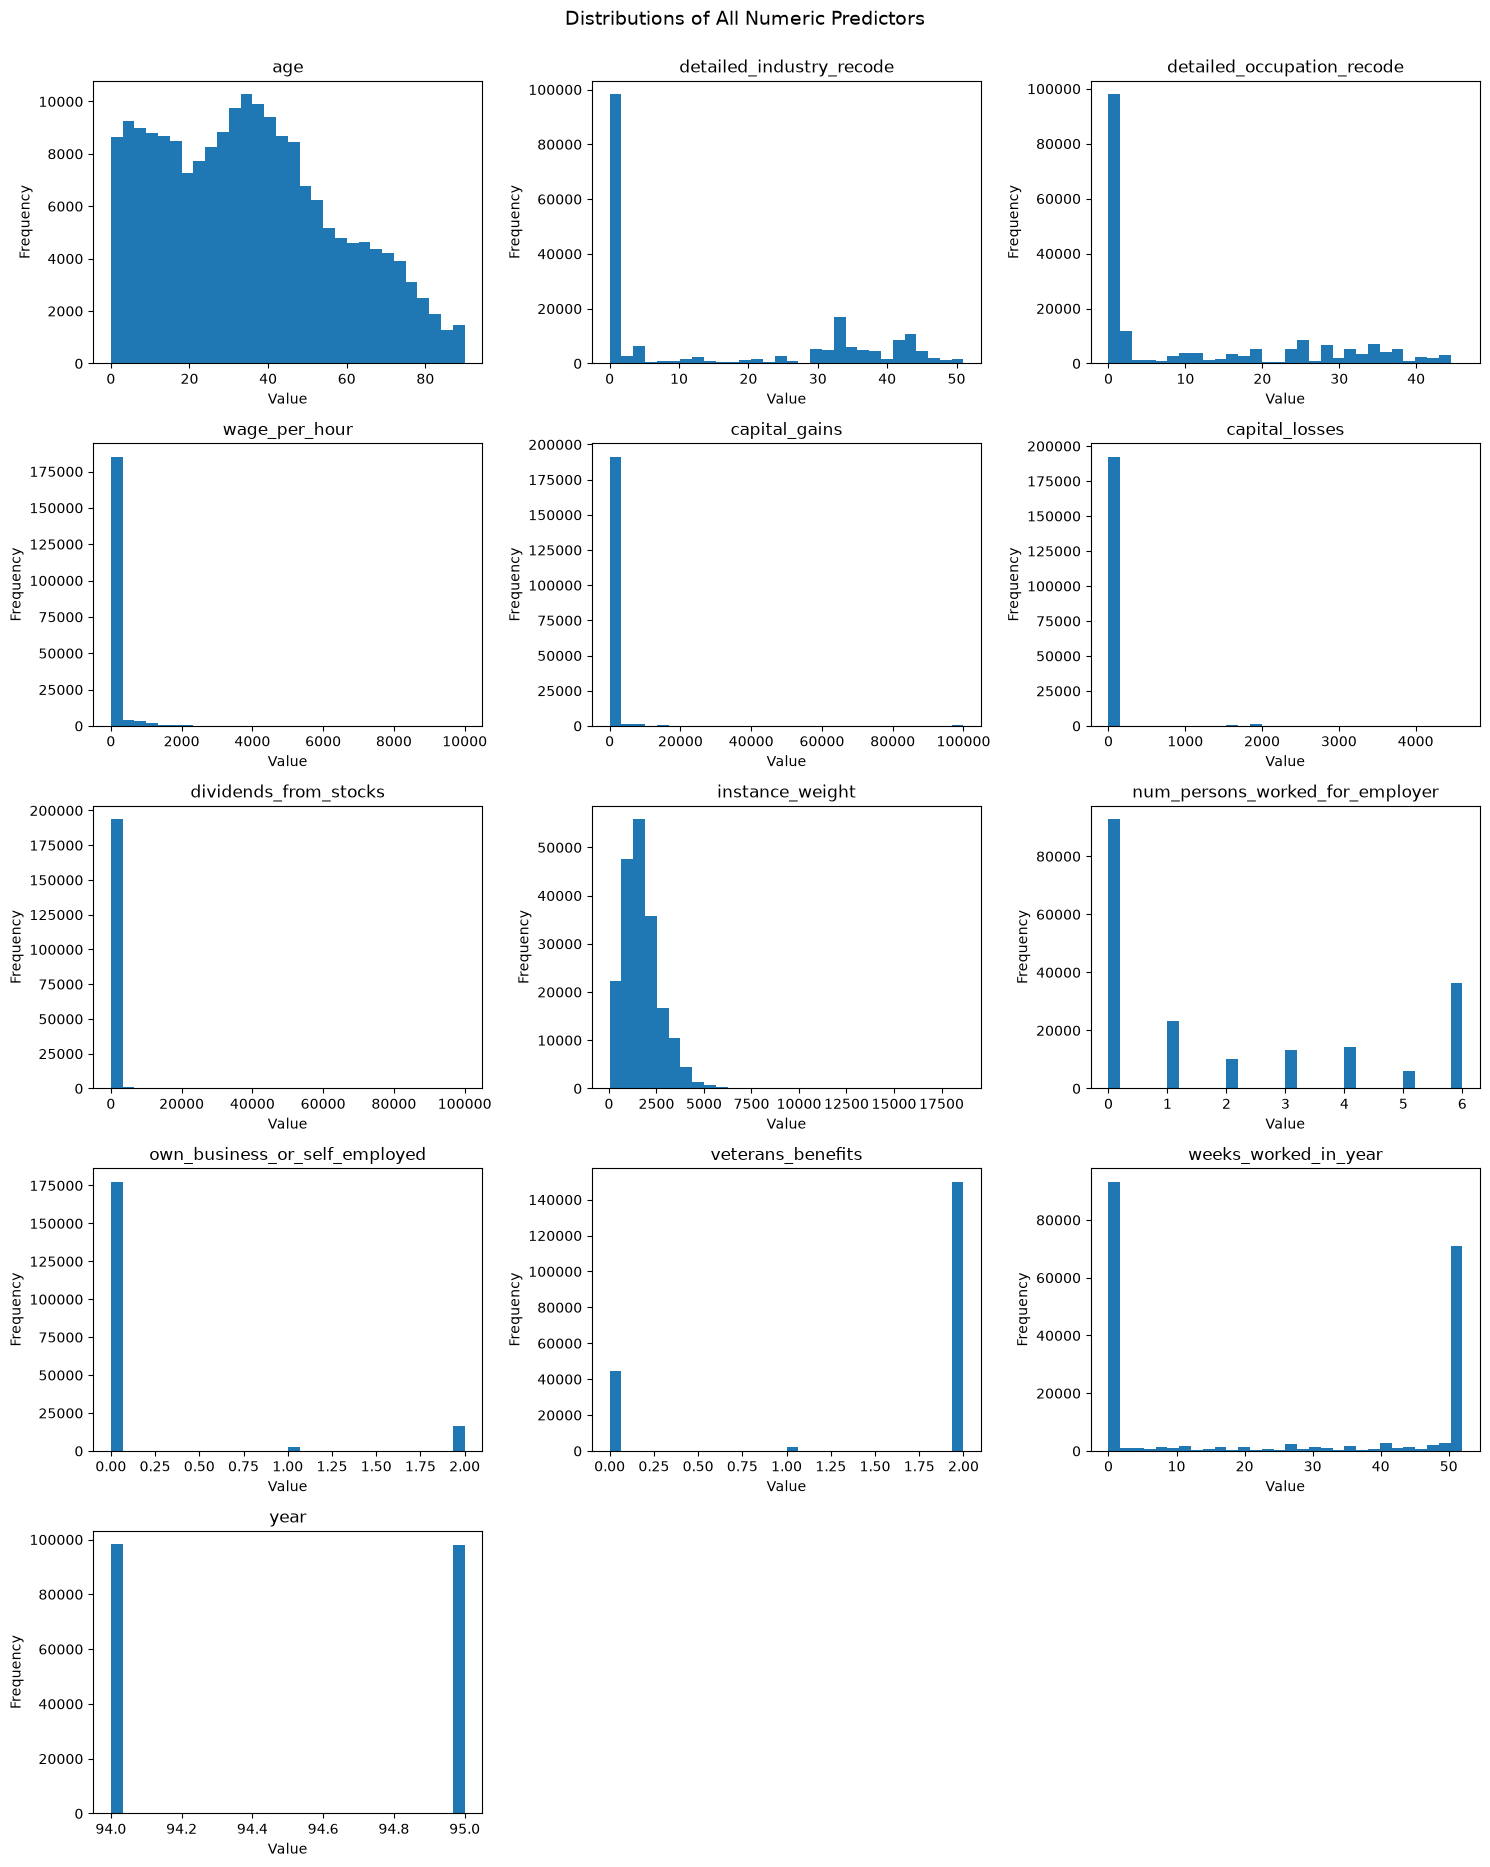

In [48]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_feature_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 3.8 * n_rows)
)
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_feature_cols):
    ax.hist(train_clean[col], bins=30)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

for ax in axes[len(numeric_feature_cols):]:
    ax.axis("off")

fig.suptitle("Distributions of All Numeric Predictors", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


### 6. Bar charts for ALL categorical predictors

Every categorical predictor is visualised with a horizontal frequency bar chart. The figure height is adjusted automatically for high-cardinality attributes so that categories remain readable.


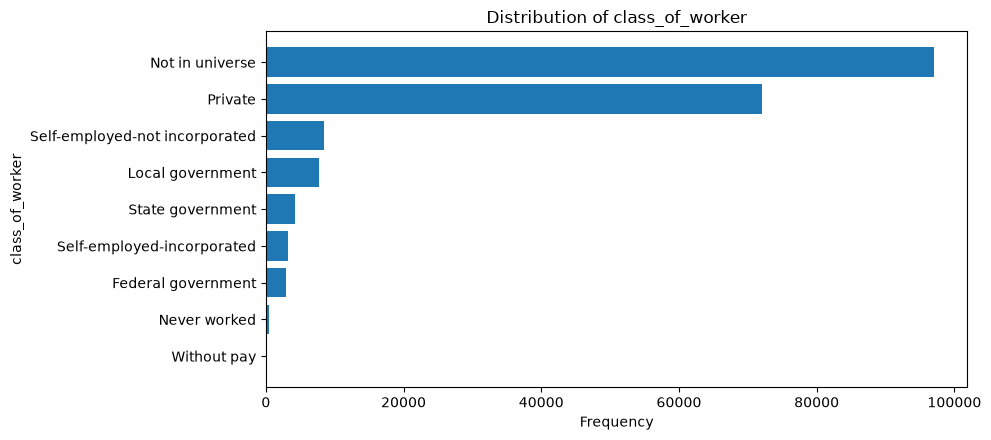

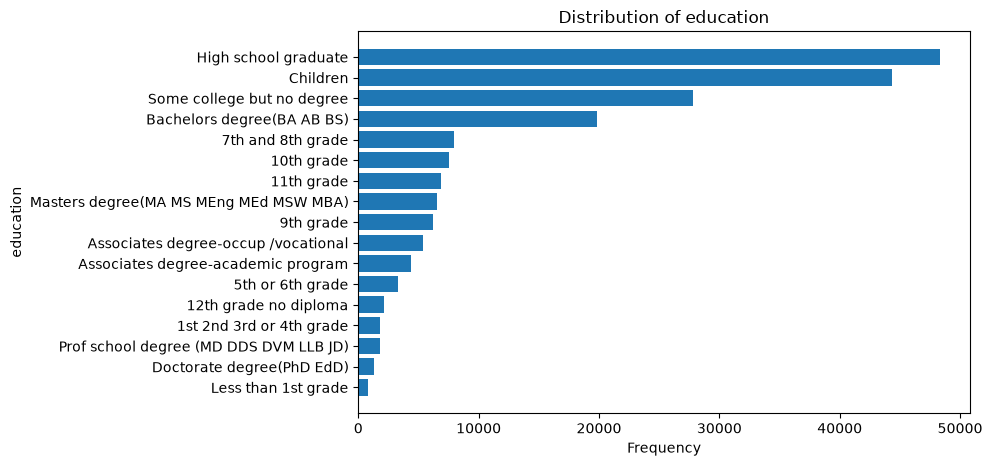

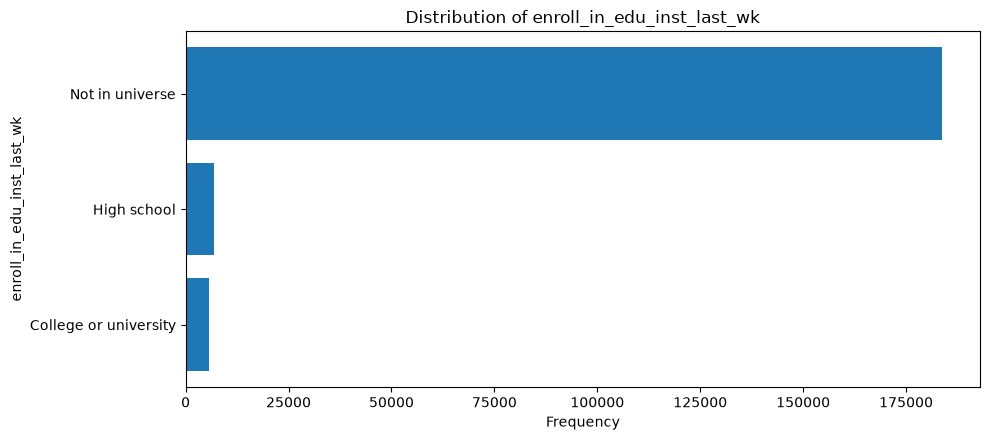

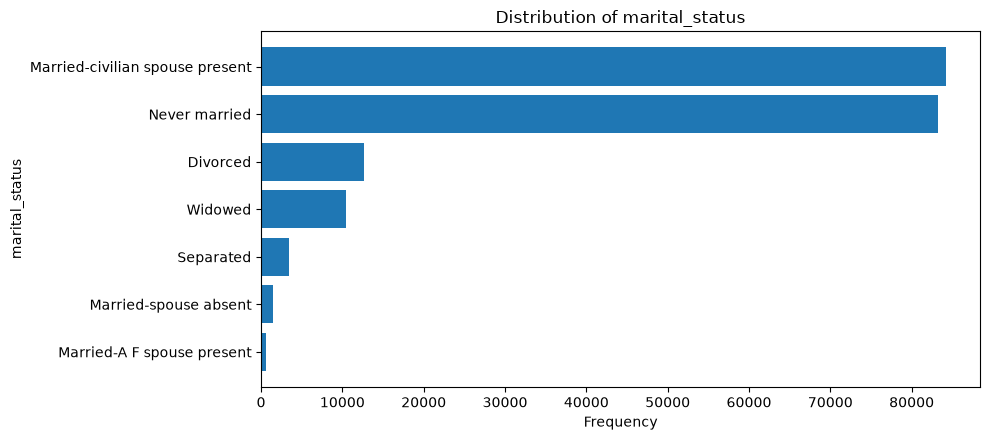

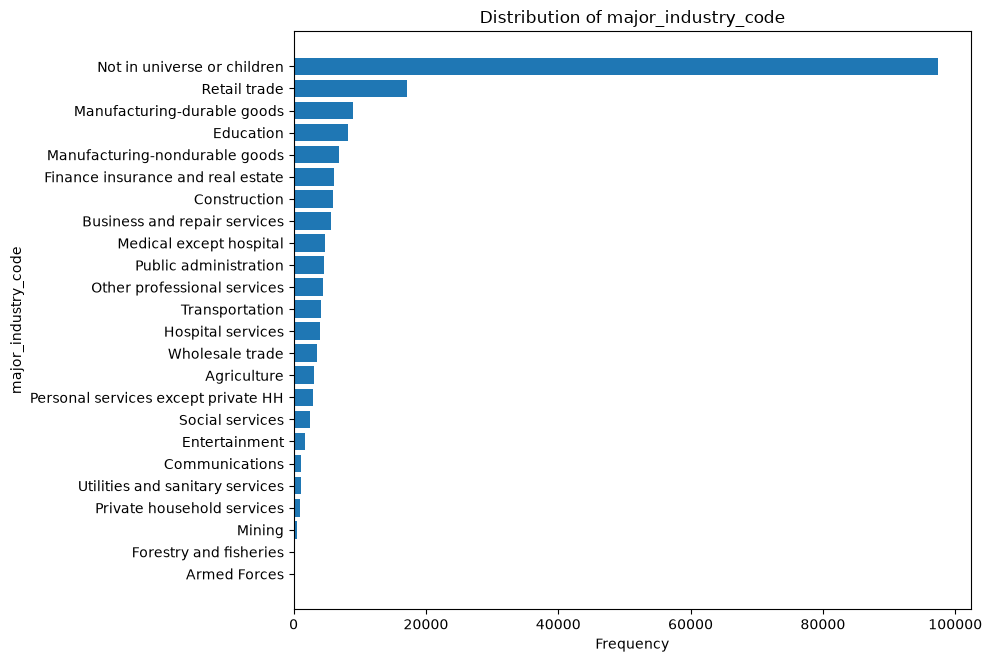

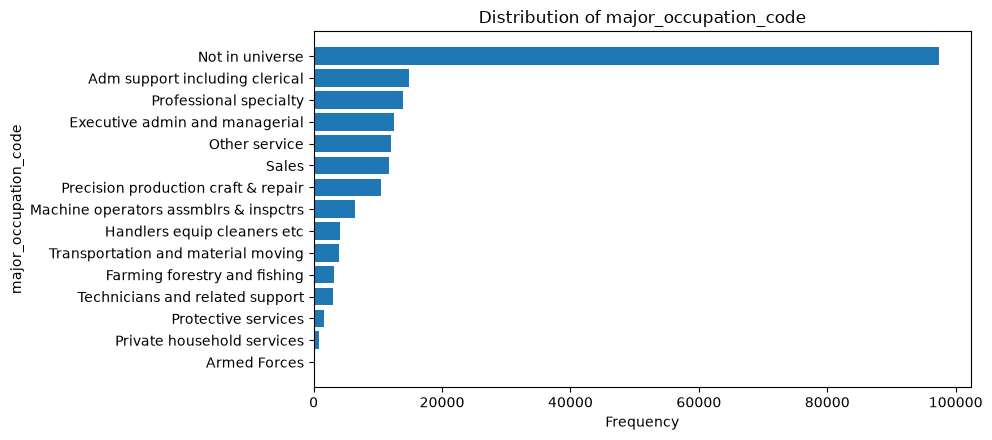

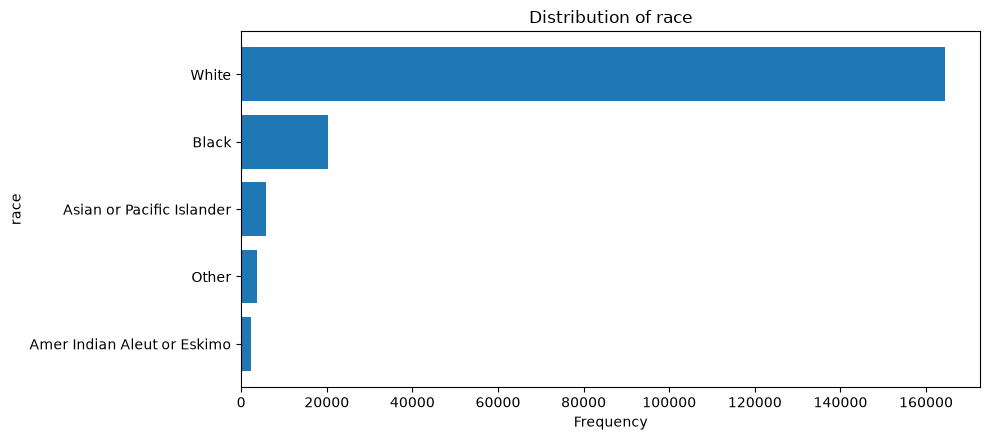

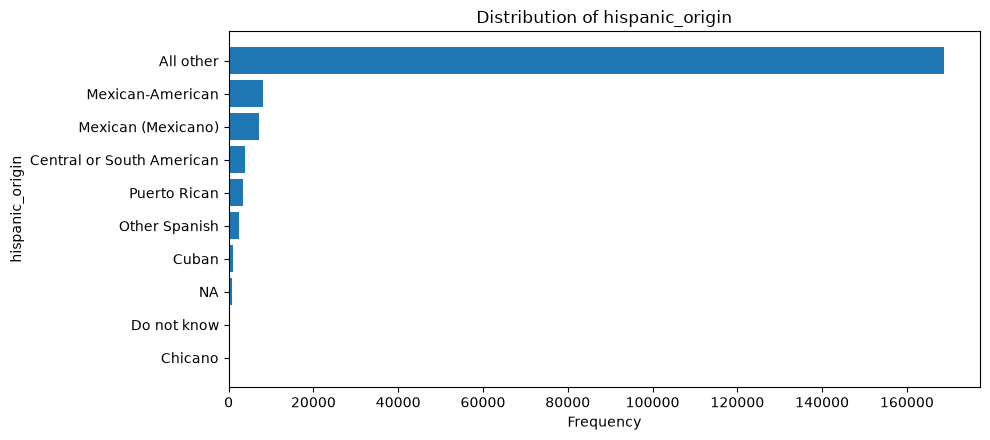

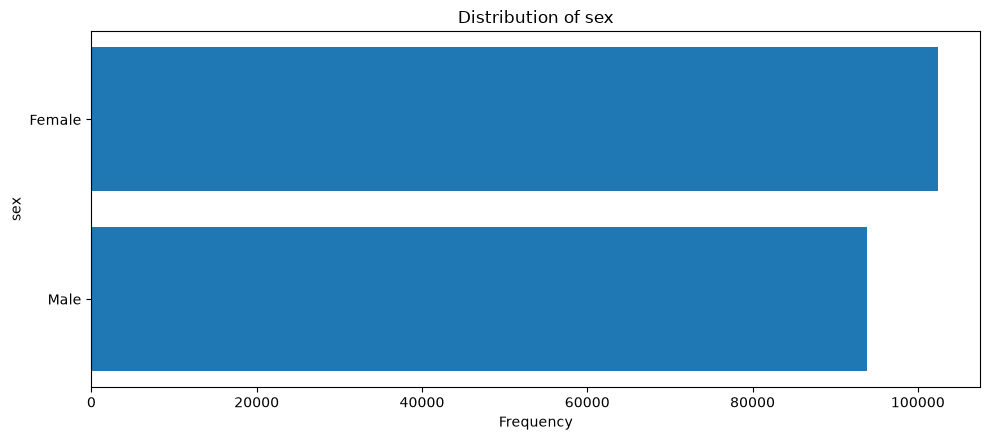

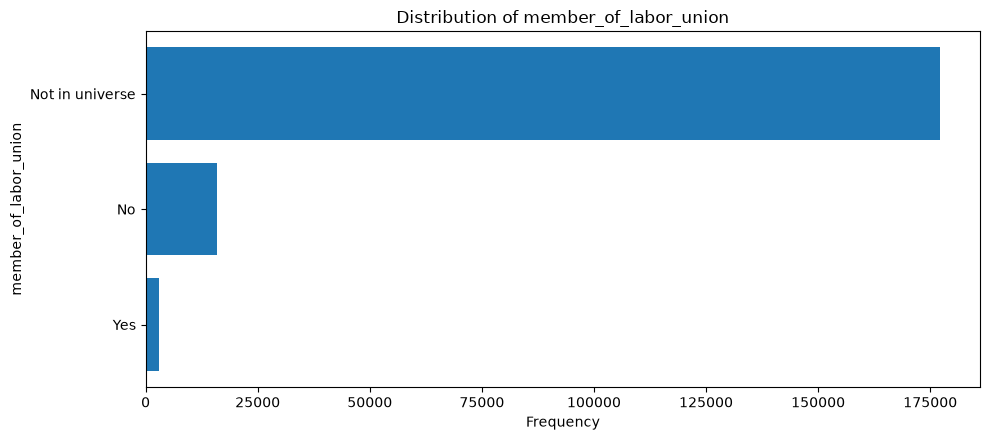

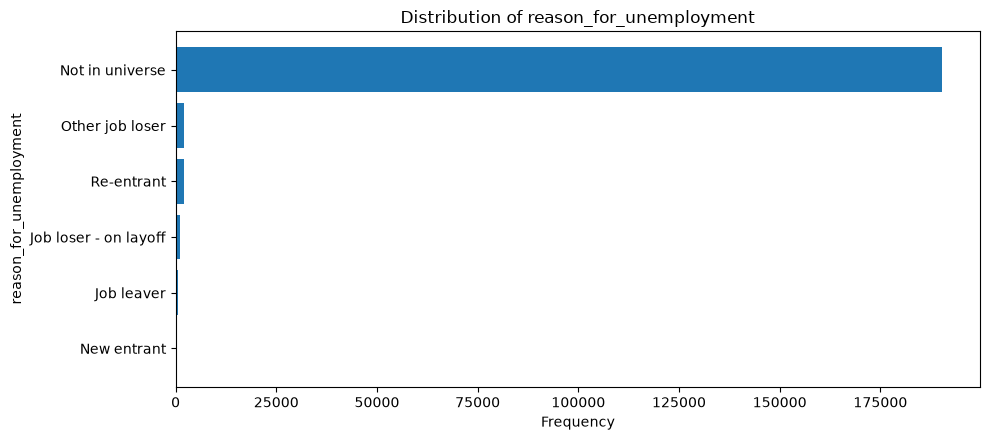

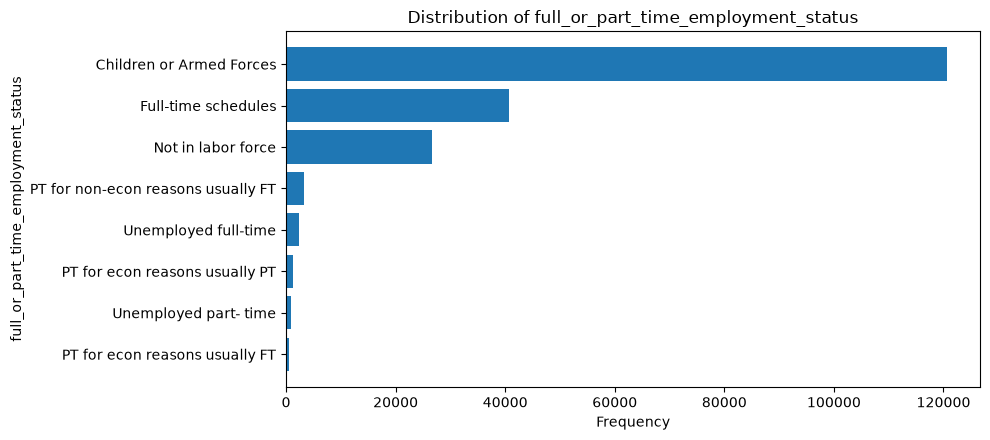

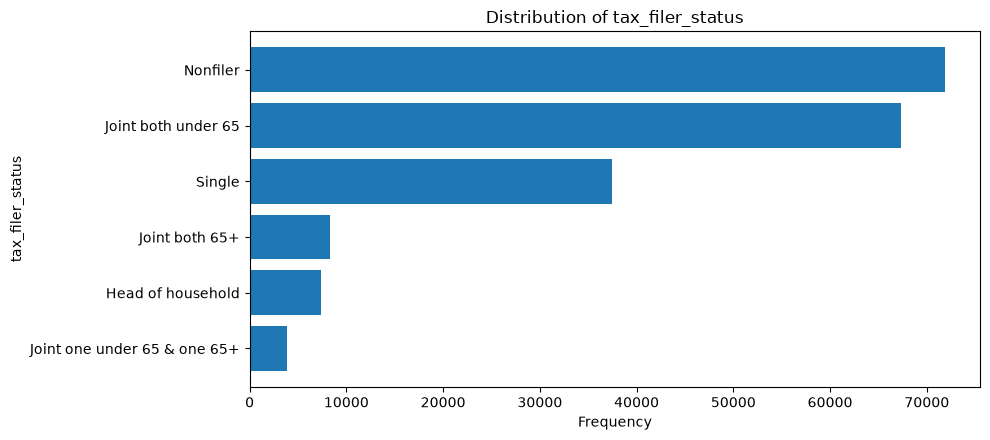

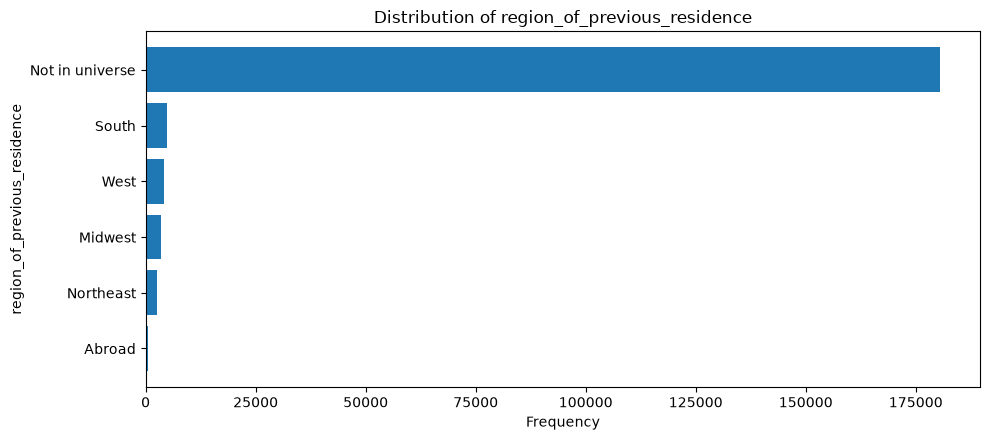

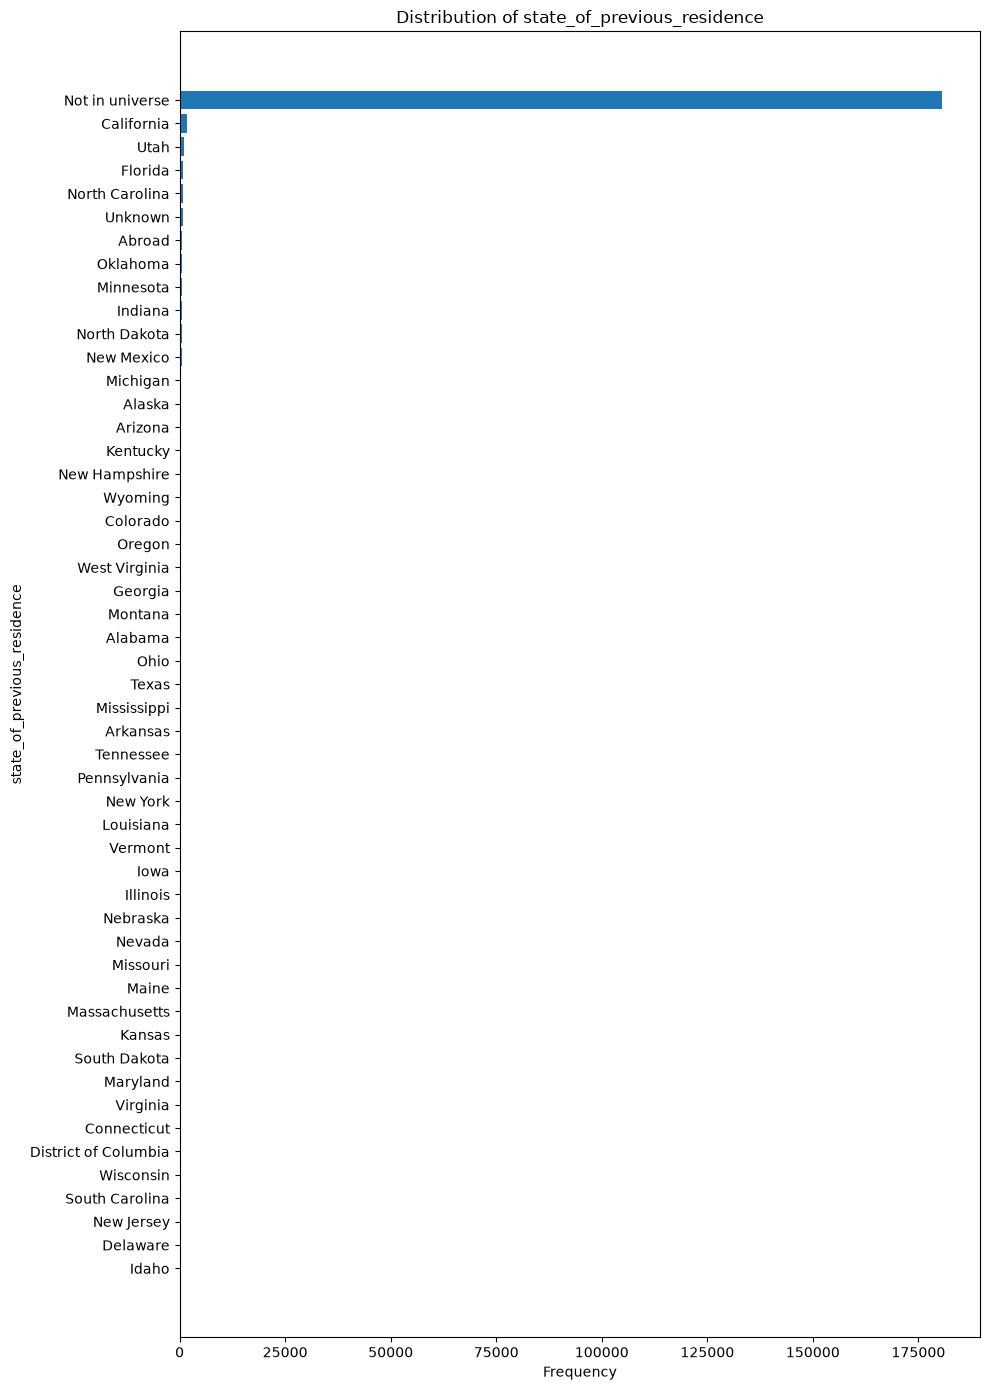

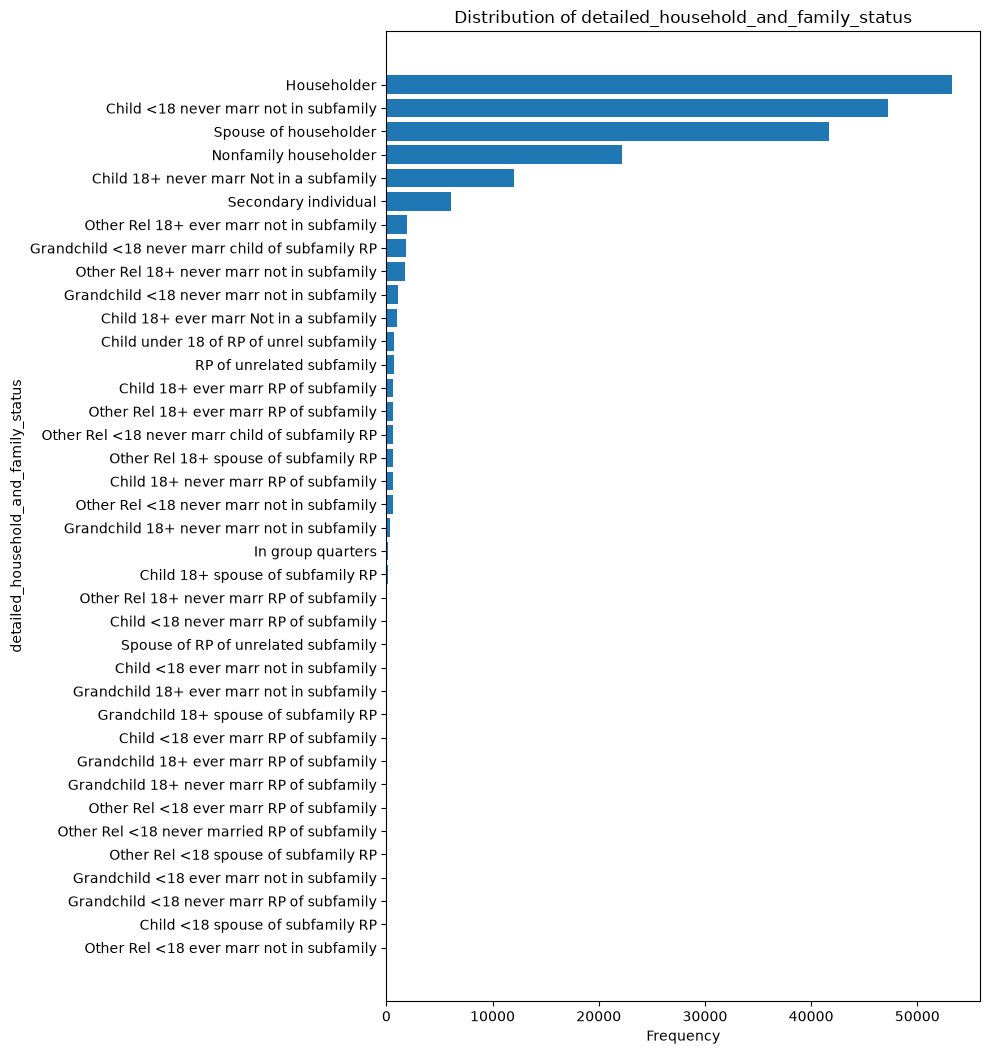

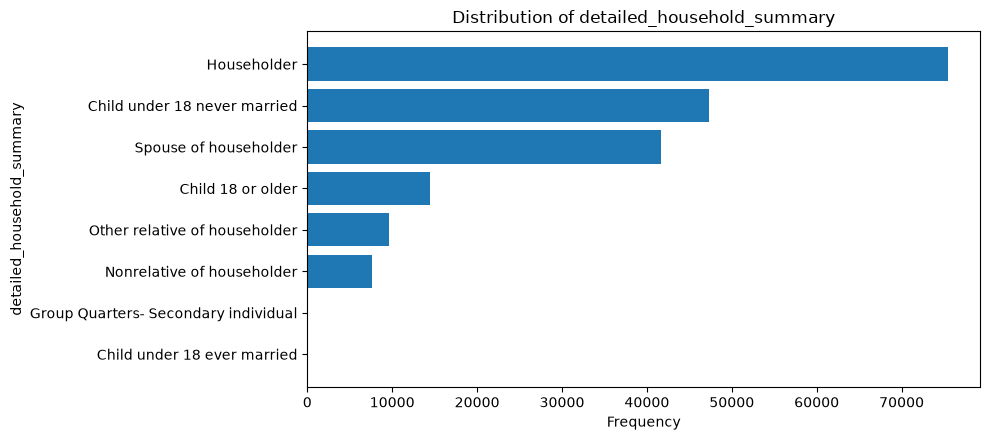

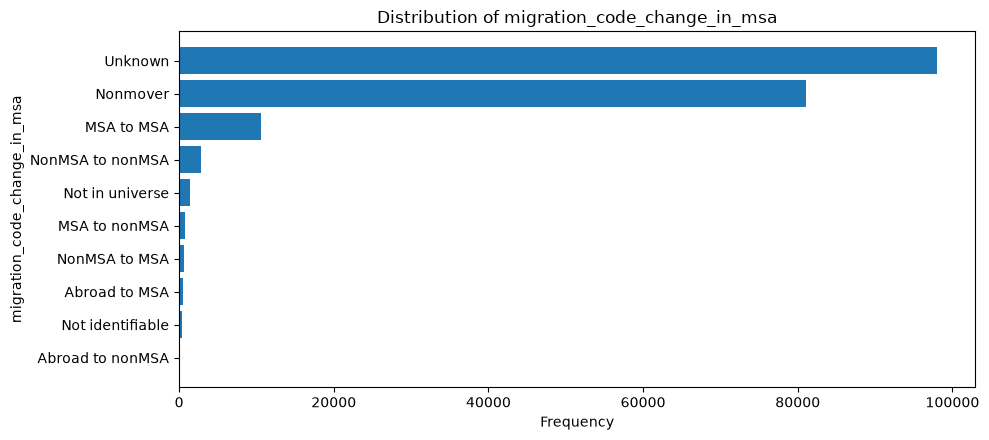

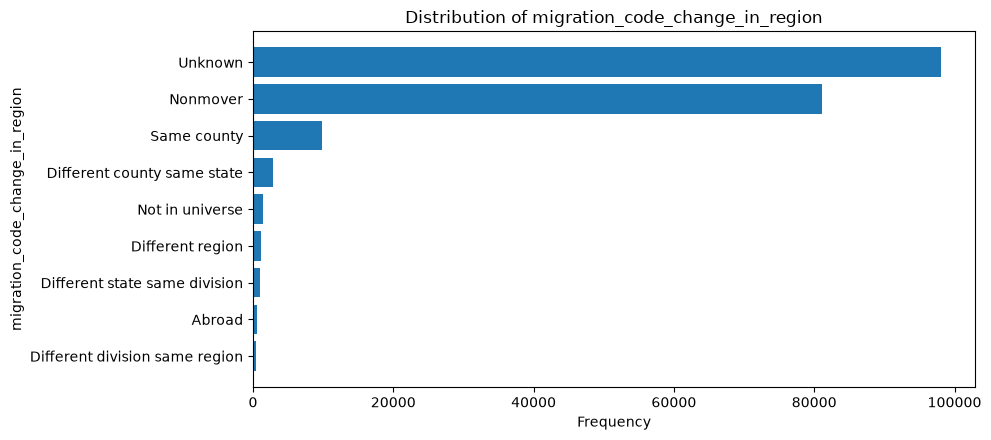

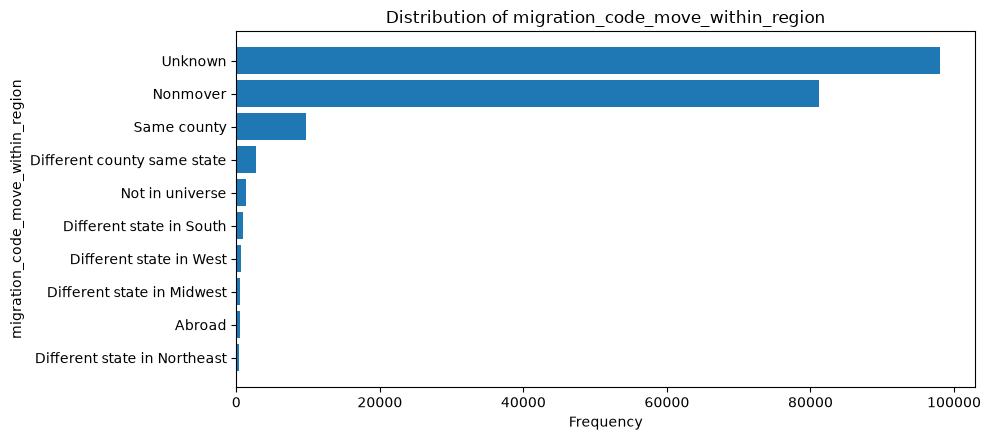

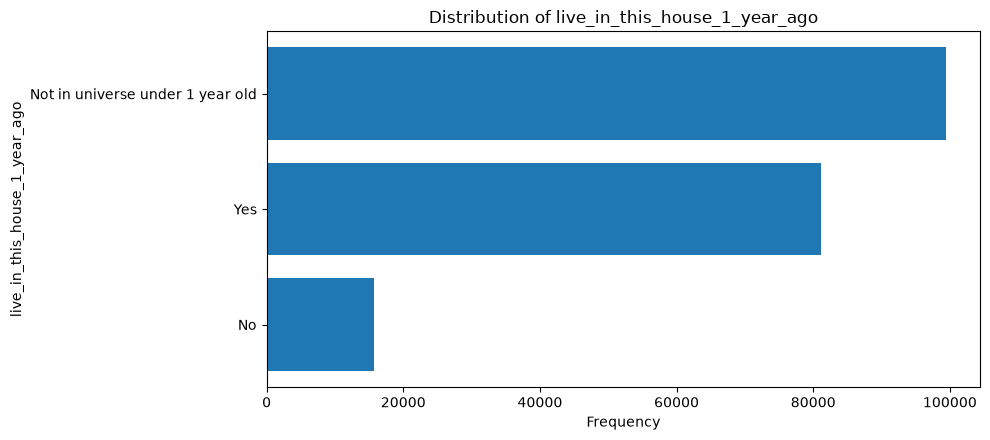

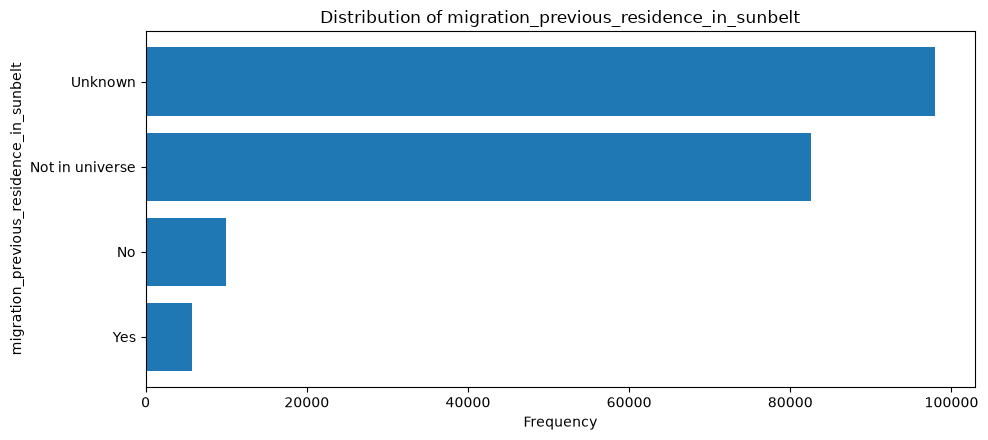

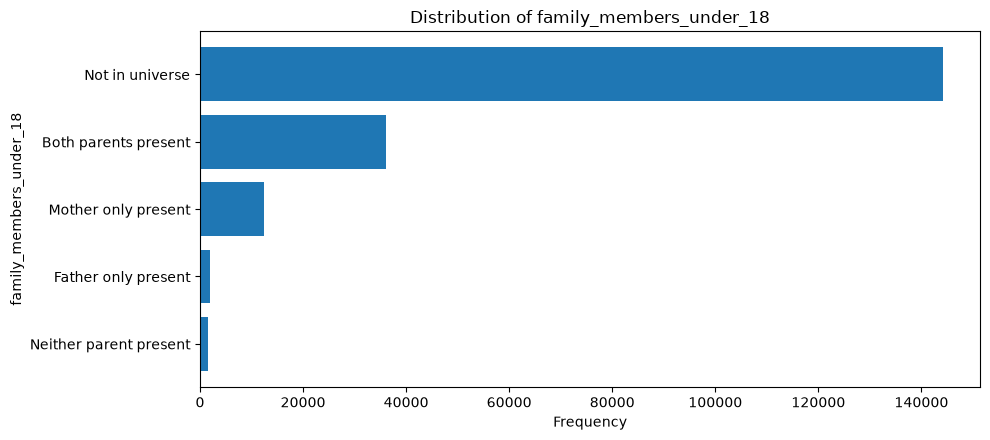

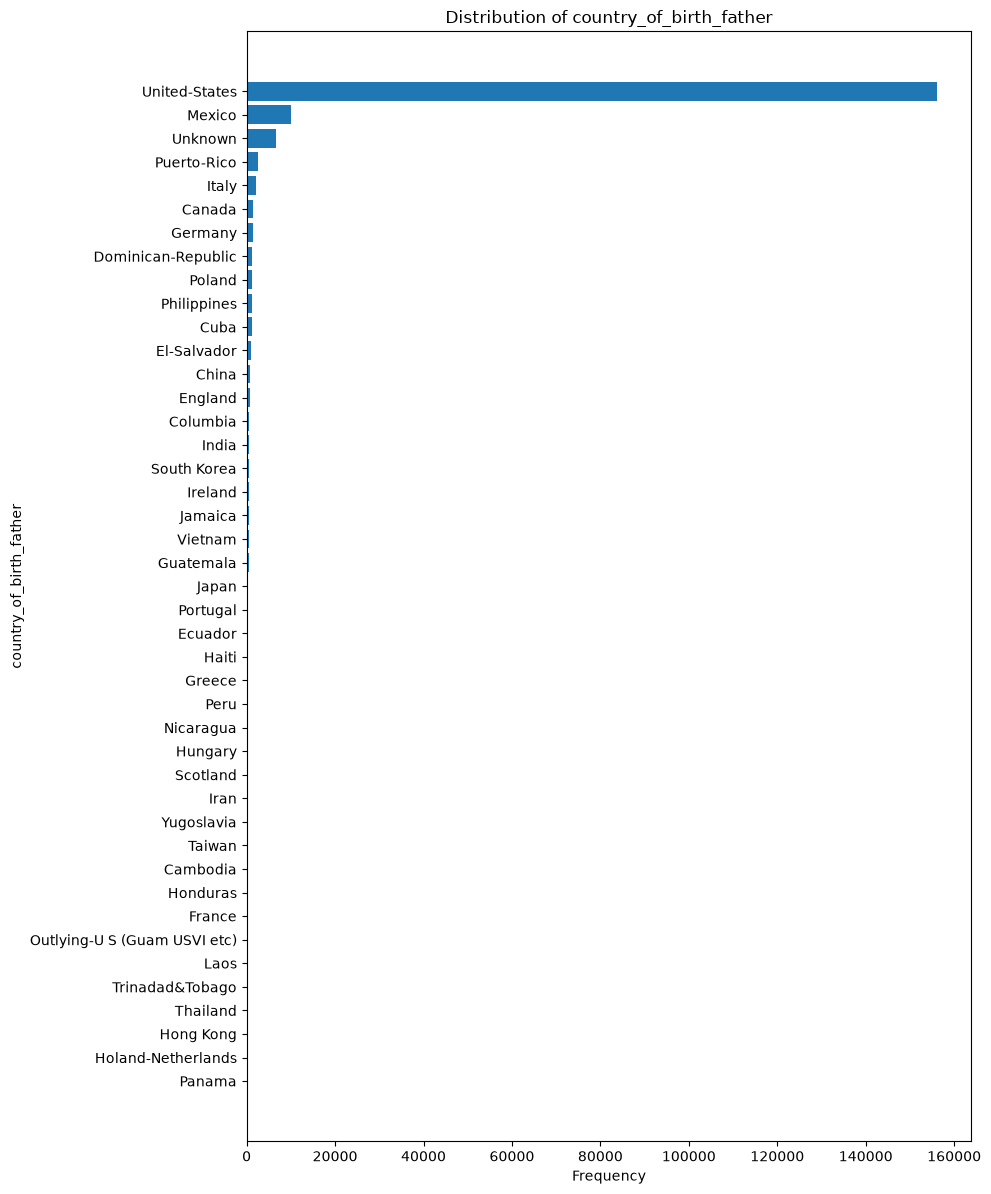

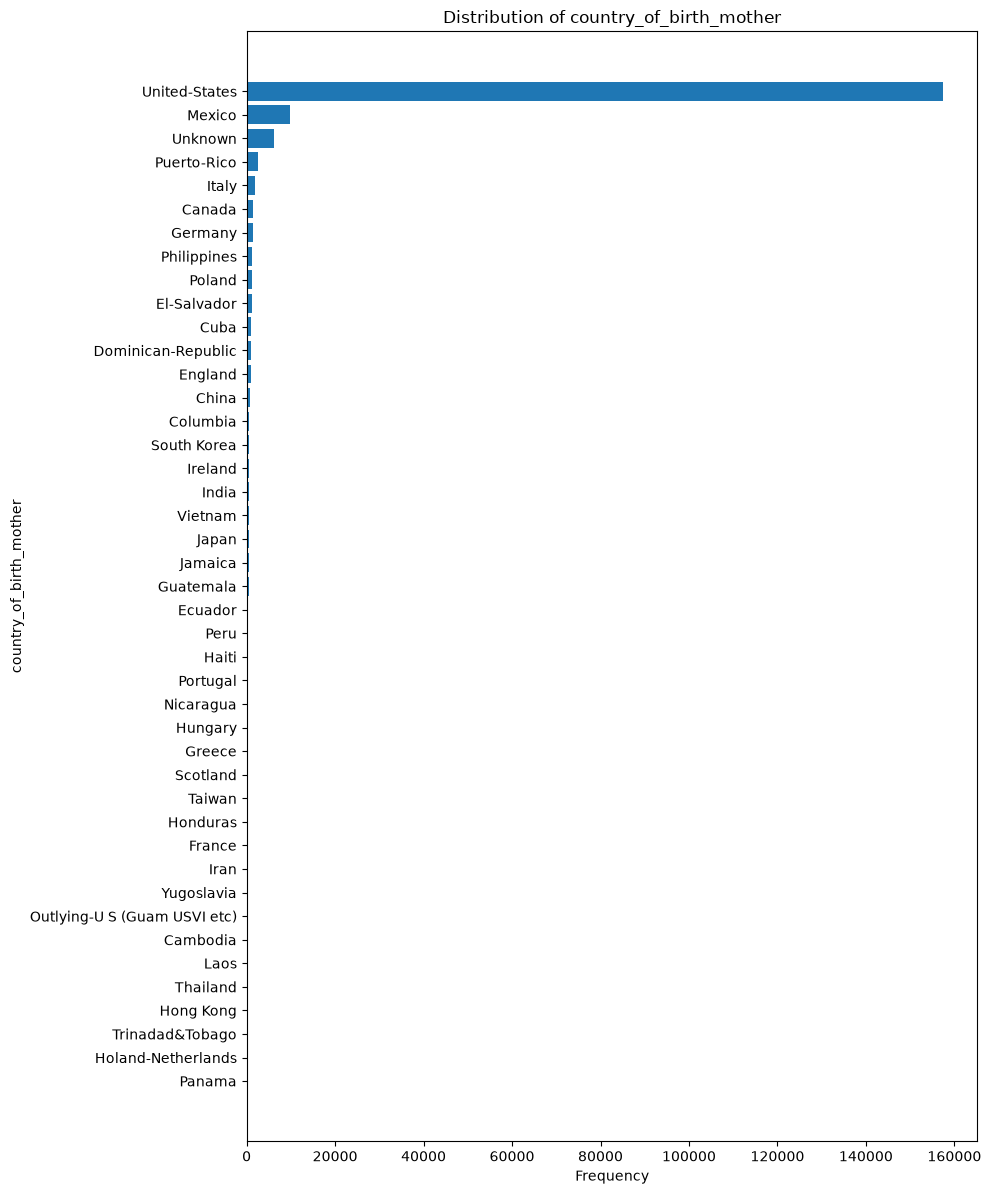

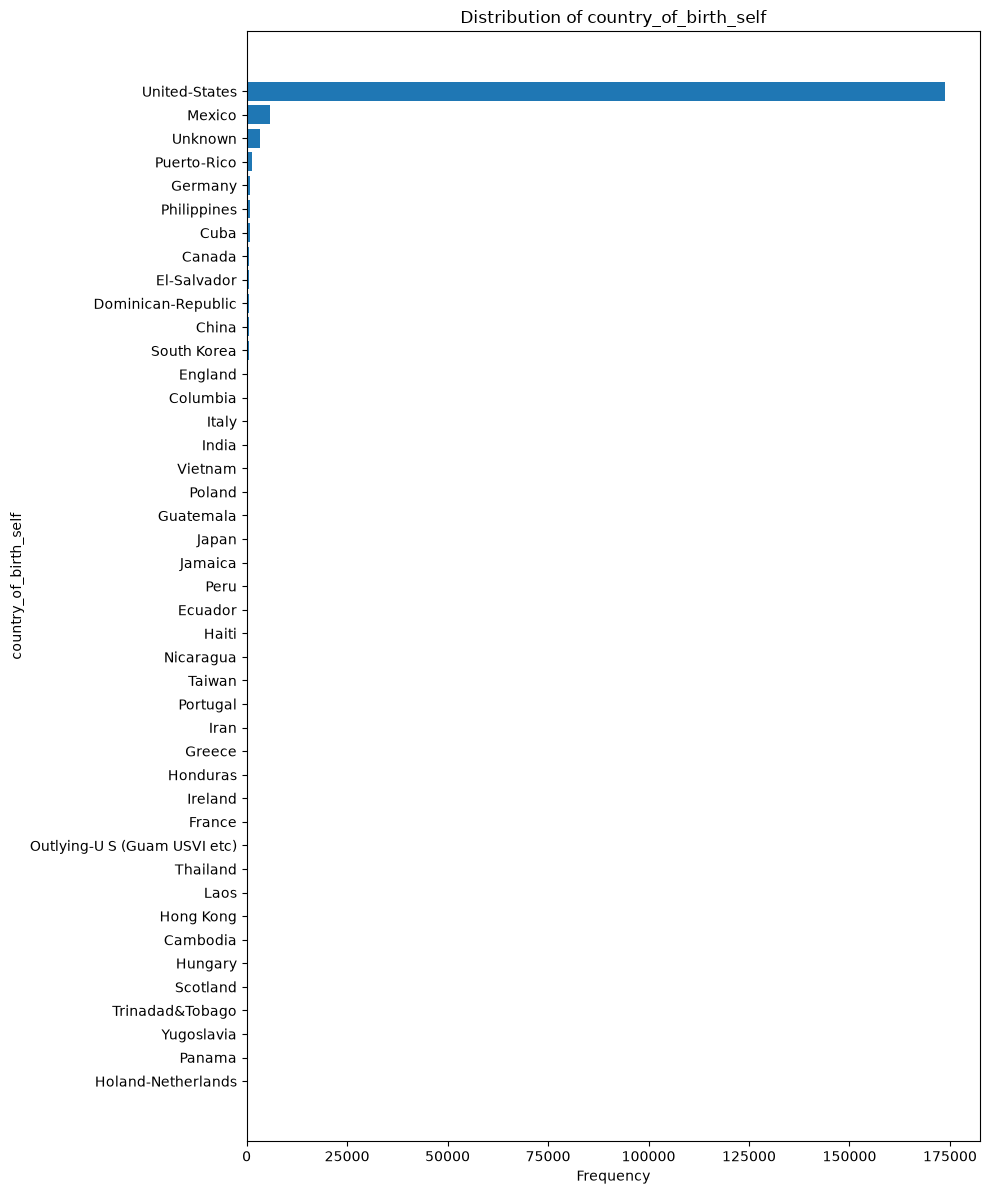

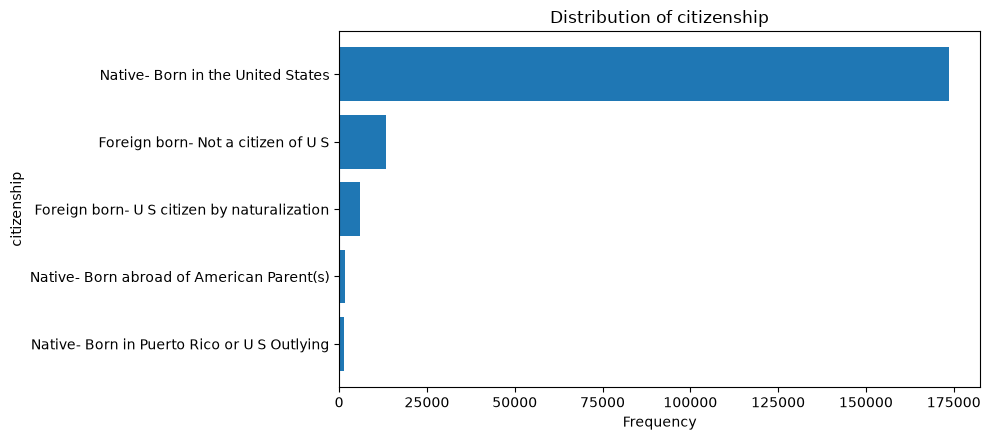

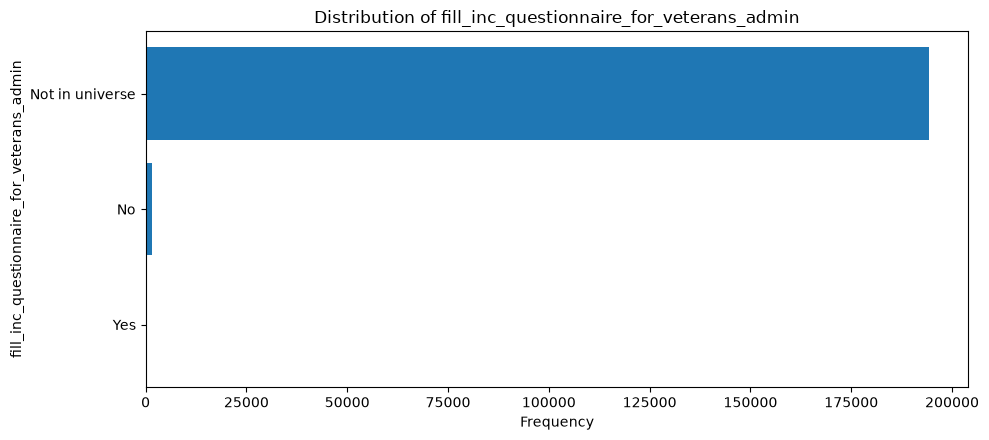

In [49]:
for col in categorical_feature_cols:
    counts = train_clean[col].value_counts().sort_values()
    fig_height = max(4.5, min(14, 0.28 * len(counts)))

    plt.figure(figsize=(10, fig_height))
    plt.barh(counts.index.astype(str), counts.values)
    plt.xlabel("Frequency")
    plt.ylabel(col)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


### 7. Boxplots and outlier investigation

Boxplots are used for the continuous/count-style numeric attributes. A sample is used only for drawing the boxplots to keep rendering responsive; the numerical IQR outlier counts below are calculated from the full cleaned training dataset.

`instance_weight` is a survey/sample-weight field rather than a conventional measured predictor. It is visualised for completeness, but its role should be decided explicitly during model construction rather than treated automatically as an ordinary feature.


C:\Users\alexa\AppData\Local\Temp\ipykernel_179008\3847618662.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(boxplot_sample[col], vert=True)
C:\Users\alexa\AppData\Local\Temp\ipykernel_179008\3847618662.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(boxplot_sample[col], vert=True)
C:\Users\alexa\AppData\Local\Temp\ipykernel_179008\3847618662.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(boxplot_sample[col], vert=True)
C:\Users\alexa\AppData\Local\Temp\ipykernel_179008\3847618662.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientatio

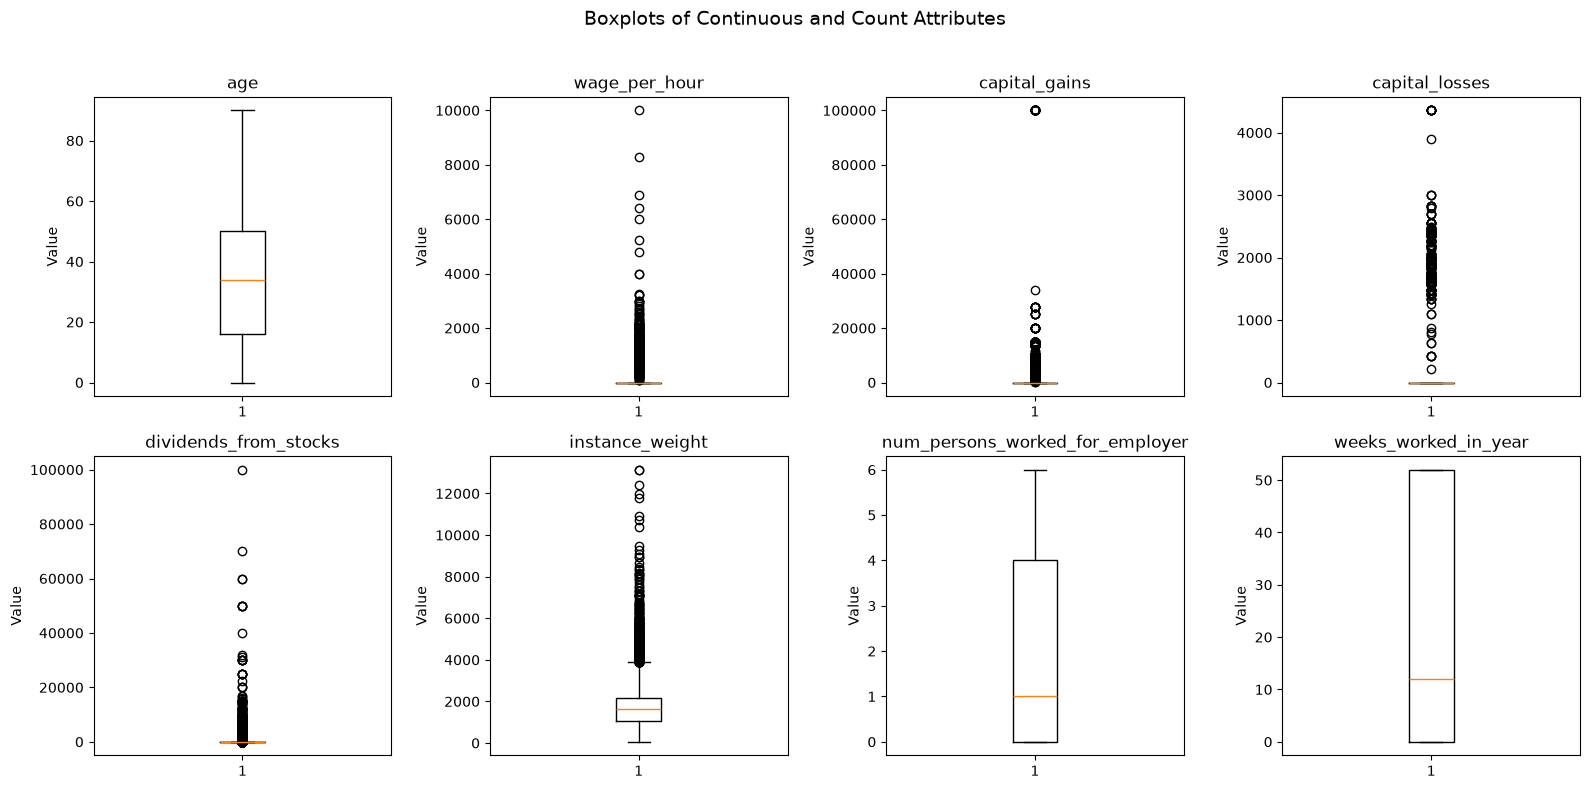

In [50]:
outlier_cols = [
    "age",
    "wage_per_hour",
    "capital_gains",
    "capital_losses",
    "dividends_from_stocks",
    "instance_weight",
    "num_persons_worked_for_employer",
    "weeks_worked_in_year"
]

boxplot_sample = train_clean[outlier_cols].sample(
    n=min(20000, len(train_clean)),
    random_state=42
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, outlier_cols):
    ax.boxplot(boxplot_sample[col], vert=True)
    ax.set_title(col)
    ax.set_ylabel("Value")

fig.suptitle("Boxplots of Continuous and Count Attributes", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [52]:
outlier_summary = []

for col in outlier_cols:
    q1 = train_clean[col].quantile(0.25)
    q3 = train_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    flagged = (
        (train_clean[col] < lower) |
        (train_clean[col] > upper)
    )

    outlier_summary.append({
        "Attribute": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower,
        "Upper bound": upper,
        "Flagged rows": int(flagged.sum()),
        "Flagged %": round(flagged.mean() * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary)


,Attribute,Q1,Q3,IQR,Lower bound,Upper bound,Flagged rows,Flagged %
0,age,16.00,50.00,34.00,-35.000,101.000,0,0.00
1,wage_per_hour,0.00,0.00,0.00,0.000,0.000,11303,5.76
2,capital_gains,0.00,0.00,0.00,0.000,0.000,7379,3.76
3,capital_losses,0.00,0.00,0.00,0.000,0.000,3906,1.99
4,dividends_from_stocks,0.00,0.00,0.00,0.000,0.000,21138,10.77
5,instance_weight,1061.53,2194.06,1132.53,-637.265,3892.855,6081,3.10
6,num_persons_worked_for_employer,0.00,4.00,4.00,-6.000,10.000,0,0.00
7,weeks_worked_in_year,0.00,52.00,52.00,-78.000,130.000,0,0.00


**Outlier interpretation.** Several income-related attributes are strongly right-skewed or zero-inflated, particularly `wage_per_hour`, `capital_gains`, `capital_losses`, and `dividends_from_stocks`. The 1.5×IQR rule can therefore flag many valid observations, especially when Q1 and Q3 are both zero. These values should not be deleted automatically. They are retained during cleaning and can be transformed, capped, or handled within a model-specific pipeline if later validation shows that this improves performance.


### 8. Numeric correlation heatmap

A correlation heatmap provides a different view of relationships among the continuous/count-style variables and the binary target.


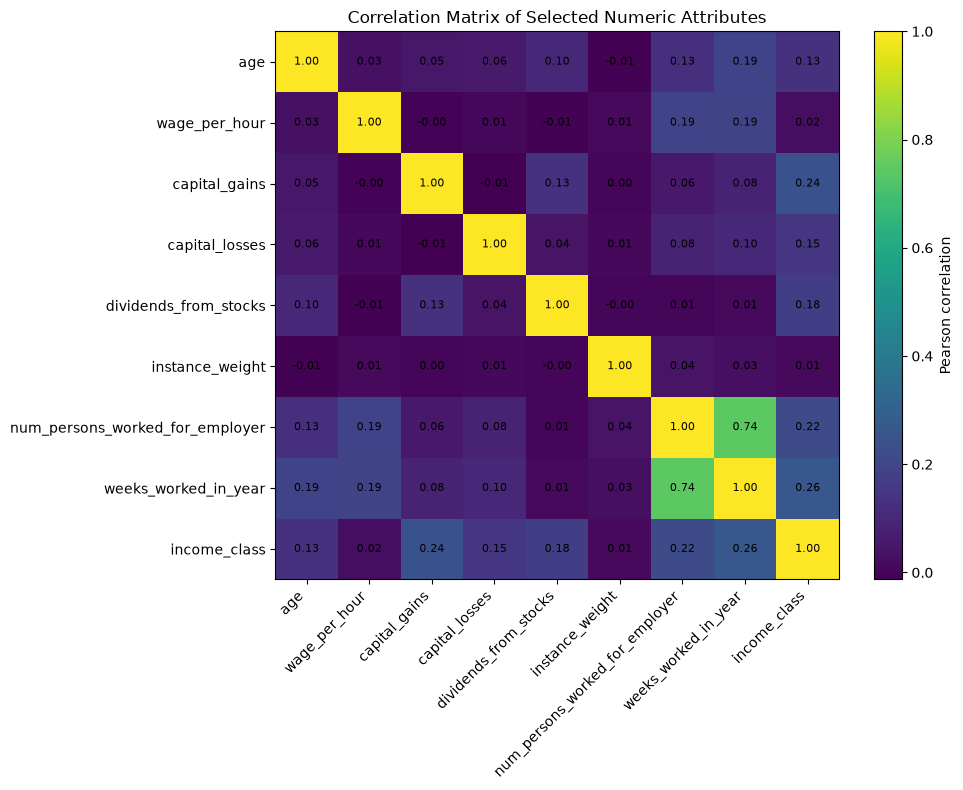

In [53]:
corr_cols = outlier_cols + ["income_class"]
corr_matrix = train_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(corr_matrix, aspect="auto")

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

fig.colorbar(image, ax=ax, label="Pearson correlation")
ax.set_title("Correlation Matrix of Selected Numeric Attributes")
plt.tight_layout()
plt.show()


### 9. Scatter plot example

A stratified sample is used for readability. The scatter plot examines the relationship between age and weeks worked in the year for the two target classes.


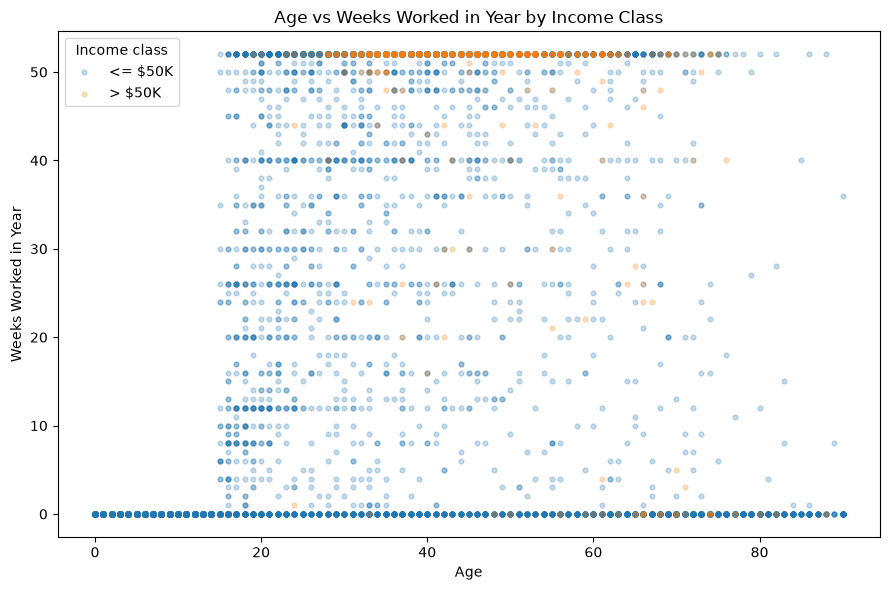

In [54]:
scatter_sample = train_clean.sample(
    n=min(8000, len(train_clean)),
    random_state=42
)

plt.figure(figsize=(9, 6))

for target_value, label in [(0, "<= $50K"), (1, "> $50K")]:
    subset = scatter_sample[
        scatter_sample["income_class"] == target_value
    ]
    plt.scatter(
        subset["age"],
        subset["weeks_worked_in_year"],
        s=12,
        alpha=0.25,
        label=label
    )

plt.xlabel("Age")
plt.ylabel("Weeks Worked in Year")
plt.title("Age vs Weeks Worked in Year by Income Class")
plt.legend(title="Income class")
plt.tight_layout()
plt.show()


### 10. Effect of duplicate removal

This chart shows the cleaning step that changes the number of rows.


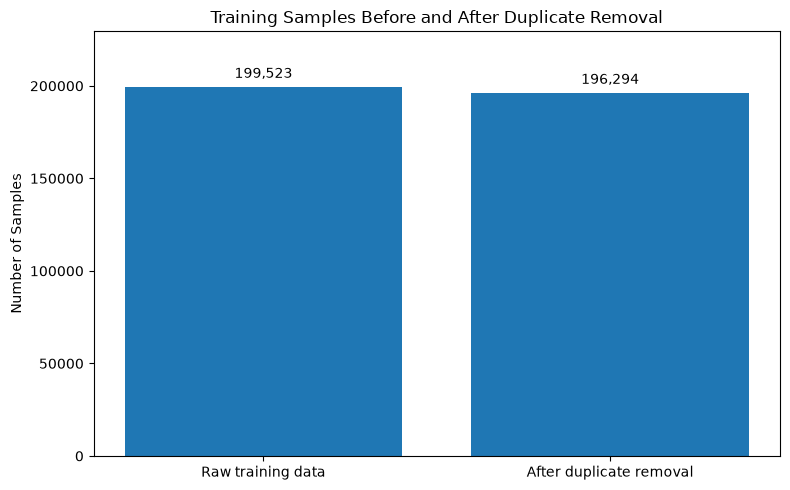

In [55]:
row_counts = pd.Series({
    "Raw training data": len(train),
    "After duplicate removal": len(train_clean)
})

plt.figure(figsize=(8, 5))
bars = plt.bar(row_counts.index, row_counts.values)

plt.ylabel("Number of Samples")
plt.title("Training Samples Before and After Duplicate Removal")
plt.ylim(0, row_counts.max() * 1.15)

for bar, count in zip(bars, row_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + row_counts.max() * 0.015,
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


### 11. Missing-value validation after cleaning

This final comparison confirms that all explicit `?` placeholders were handled by the cleaning pipeline.


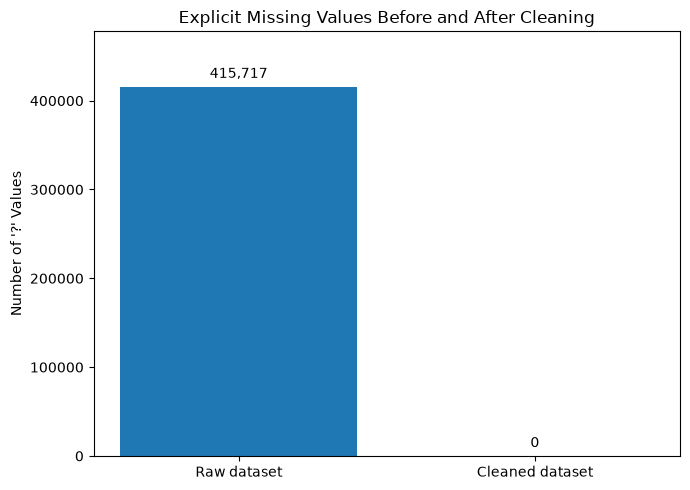

In [56]:
raw_missing = (train_raw_viz == "?").sum().sum()
clean_missing = (train_clean == "?").sum().sum()

missing_comparison = pd.Series({
    "Raw dataset": raw_missing,
    "Cleaned dataset": clean_missing
})

plt.figure(figsize=(7, 5))
bars = plt.bar(missing_comparison.index, missing_comparison.values)

plt.ylabel("Number of '?' Values")
plt.title("Explicit Missing Values Before and After Cleaning")
plt.ylim(0, max(raw_missing * 1.15, 1))

for bar, count in zip(bars, missing_comparison.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + raw_missing * 0.015,
        f"{int(count):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


In [57]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# EXPORT SETTINGS
# ============================================================

EXPORT_ROOT = Path("visualizations")

folders = {
    "missing": EXPORT_ROOT / "01_missing_values",
    "target": EXPORT_ROOT / "02_target_distribution",
    "numeric_hist": EXPORT_ROOT / "03_numeric_histograms",
    "numeric_box": EXPORT_ROOT / "04_numeric_boxplots",
    "categorical": EXPORT_ROOT / "05_categorical_barcharts",
    "preprocessing": EXPORT_ROOT / "06_preprocessing",
    "correlation": EXPORT_ROOT / "07_correlation",
    "scatter": EXPORT_ROOT / "08_scatterplots",
}

for folder in folders.values():
    folder.mkdir(parents=True, exist_ok=True)

DPI = 300
SHOW_PLOTS = False


def safe_filename(name):
    """Convert column/title text to a safe filename."""
    name = str(name).strip()
    name = re.sub(r"[^\w\-]+", "_", name)
    return name.strip("_")


def save_plot(path):
    """Save current matplotlib figure."""
    plt.tight_layout()
    plt.savefig(
        path,
        dpi=DPI,
        bbox_inches="tight"
    )

    if SHOW_PLOTS:
        plt.show()

    plt.close()


# ============================================================
# PREPARE RAW VISUALISATION COPY
# ============================================================

train_raw_viz = train.copy()

string_cols_raw = train_raw_viz.select_dtypes(
    include=["object", "str"]
).columns

for col in string_cols_raw:
    train_raw_viz[col] = (
        train_raw_viz[col]
        .astype(str)
        .str.strip()
    )


# ============================================================
# 1. MISSING VALUES
# ============================================================

missing_counts = (train_raw_viz == "?").sum()
missing_counts = missing_counts[
    missing_counts > 0
].sort_values()

missing_percent = (
    missing_counts / len(train_raw_viz) * 100
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    missing_percent.index,
    missing_percent.values
)

plt.xlabel("Missing values (%)")
plt.ylabel("Attribute")
plt.title("Missing Values in Raw Training Dataset")

plt.xlim(
    0,
    missing_percent.max() * 1.15
)

for bar, value in zip(
    bars,
    missing_percent.values
):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

save_plot(
    folders["missing"] /
    "missing_values_raw_training.png"
)


# ============================================================
# 2. TARGET CLASS DISTRIBUTION
# ============================================================

target_counts = (
    train_clean["income_class"]
    .value_counts()
    .sort_index()
)

target_labels = [
    "<= $50K",
    "> $50K"
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    target_labels,
    target_counts.values
)

plt.xlabel("Income Class")
plt.ylabel("Number of Samples")
plt.title("Income Class Distribution After Cleaning")

# Extra headroom so labels do not overlap title
plt.ylim(
    0,
    target_counts.max() * 1.18
)

for bar, count in zip(
    bars,
    target_counts.values
):
    percentage = (
        count / len(train_clean) * 100
    )

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() +
        target_counts.max() * 0.015,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

save_plot(
    folders["target"] /
    "income_class_distribution.png"
)


# ============================================================
# DETECT NUMERIC / CATEGORICAL ATTRIBUTES
# ============================================================

numeric_cols = (
    train_clean
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

# Target is already shown separately
numeric_predictors = [
    col for col in numeric_cols
    if col != "income_class"
]

categorical_cols = (
    train_clean
    .select_dtypes(include=["object", "str", "category"])
    .columns
    .tolist()
)

print("Numeric predictors:", len(numeric_predictors))
print("Categorical predictors:", len(categorical_cols))


# ============================================================
# 3. NUMERIC HISTOGRAMS
# ============================================================

for col in numeric_predictors:

    plt.figure(figsize=(8, 5))

    plt.hist(
        train_clean[col].dropna(),
        bins=30
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(
        f"Distribution of {col}"
    )

    save_plot(
        folders["numeric_hist"] /
        f"{safe_filename(col)}_histogram.png"
    )


# ============================================================
# 4. NUMERIC BOXPLOTS
# ============================================================

for col in numeric_predictors:

    plt.figure(figsize=(8, 3.5))

    plt.boxplot(
        train_clean[col].dropna(),
        vert=False
    )

    plt.xlabel(col)
    plt.title(
        f"Boxplot of {col}"
    )

    save_plot(
        folders["numeric_box"] /
        f"{safe_filename(col)}_boxplot.png"
    )


# ============================================================
# 5. ALL CATEGORICAL ATTRIBUTES
# ============================================================

for col in categorical_cols:

    counts = (
        train_clean[col]
        .astype(str)
        .value_counts(dropna=False)
    )

    # Horizontal layout works better for long labels
    plt.figure(
        figsize=(
            11,
            max(5, len(counts) * 0.30)
        )
    )

    bars = plt.barh(
        counts.index.astype(str),
        counts.values
    )

    plt.xlabel("Frequency")
    plt.ylabel(col)
    plt.title(
        f"Distribution of {col}"
    )

    plt.gca().invert_yaxis()

    # Add slight right margin
    plt.xlim(
        0,
        counts.max() * 1.08
    )

    save_plot(
        folders["categorical"] /
        f"{safe_filename(col)}_barchart.png"
    )


# ============================================================
# 6. PREPROCESSING VISUALISATIONS
# ============================================================

# 6A. Rows before / after duplicate removal

row_counts = pd.Series({
    "Raw training data":
        len(train),
    "After duplicate removal":
        len(train_clean)
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    row_counts.index,
    row_counts.values
)

plt.ylabel("Number of Samples")
plt.title(
    "Training Samples Before and After Cleaning"
)

plt.ylim(
    0,
    row_counts.max() * 1.15
)

for bar, count in zip(
    bars,
    row_counts.values
):
    plt.text(
        bar.get_x() +
        bar.get_width() / 2,
        bar.get_height() +
        row_counts.max() * 0.01,
        f"{count:,}",
        ha="center"
    )

save_plot(
    folders["preprocessing"] /
    "samples_before_after_cleaning.png"
)


# 6B. Explicit missing placeholders before / after

raw_missing = (
    train_raw_viz == "?"
).sum().sum()

clean_missing = (
    train_clean == "?"
).sum().sum()

missing_comparison = pd.Series({
    "Raw dataset":
        raw_missing,
    "Cleaned dataset":
        clean_missing
})

plt.figure(figsize=(7, 5))

bars = plt.bar(
    missing_comparison.index,
    missing_comparison.values
)

plt.ylabel("Number of '?' Values")
plt.title(
    "Explicit Missing Values Before and After Cleaning"
)

plt.ylim(
    0,
    max(missing_comparison.max() * 1.15, 1)
)

for bar, count in zip(
    bars,
    missing_comparison.values
):
    plt.text(
        bar.get_x() +
        bar.get_width() / 2,
        bar.get_height() +
        max(missing_comparison.max(), 1) * 0.01,
        f"{int(count):,}",
        ha="center"
    )

save_plot(
    folders["preprocessing"] /
    "missing_before_after_cleaning.png"
)


# ============================================================
# 7. NUMERIC CORRELATION HEATMAP
# ============================================================

corr_cols = numeric_predictors + ["income_class"]

corr = (
    train_clean[corr_cols]
    .corr(numeric_only=True)
)

fig, ax = plt.subplots(
    figsize=(12, 10)
)

image = ax.imshow(
    corr.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(corr.columns))
)

ax.set_yticks(
    range(len(corr.index))
)

ax.set_xticklabels(
    corr.columns,
    rotation=90
)

ax.set_yticklabels(
    corr.index
)

plt.colorbar(
    image,
    ax=ax,
    label="Correlation"
)

plt.title(
    "Correlation Matrix of Numeric Attributes"
)

save_plot(
    folders["correlation"] /
    "numeric_correlation_heatmap.png"
)


# ============================================================
# 8. SCATTER PLOTS
# ============================================================

scatter_pairs = [
    (
        "age",
        "weeks_worked_in_year"
    ),
    (
        "capital_gains",
        "dividends_from_stocks"
    ),
    (
        "wage_per_hour",
        "weeks_worked_in_year"
    )
]

for x_col, y_col in scatter_pairs:

    # Only run if both attributes exist
    if (
        x_col not in train_clean.columns
        or
        y_col not in train_clean.columns
    ):
        continue

    # Sample to keep the plot readable
    sample = train_clean[
        [x_col, y_col]
    ].sample(
        n=min(
            10000,
            len(train_clean)
        ),
        random_state=42
    )

    plt.figure(figsize=(8, 6))

    plt.scatter(
        sample[x_col],
        sample[y_col],
        alpha=0.25,
        s=8
    )

    plt.xlabel(x_col)
    plt.ylabel(y_col)

    plt.title(
        f"{x_col} vs {y_col}"
    )

    save_plot(
        folders["scatter"] /
        (
            f"{safe_filename(x_col)}"
            f"_vs_"
            f"{safe_filename(y_col)}.png"
        )
    )


# ============================================================
# FINISHED
# ============================================================

print("\nAll visualisations exported successfully.")
print("Output folder:")
print(EXPORT_ROOT.resolve())

for name, folder in folders.items():
    n_files = len(
        list(folder.glob("*.png"))
    )

    print(
        f"{name:15s}: "
        f"{n_files} files"
    )

Numeric predictors: 13
Categorical predictors: 28


C:\Users\alexa\AppData\Local\Temp\ipykernel_179008\2391250586.py:233: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(
C:\Users\alexa\AppData\Local\Temp\ipykernel_179008\2391250586.py:233: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(
C:\Users\alexa\AppData\Local\Temp\ipykernel_179008\2391250586.py:233: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(
C:\Users\alexa\AppData\Local\Temp\ipykernel_179008\2391250586.py:233: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(
C:\Users\alexa\AppData\Local\Tem


All visualisations exported successfully.
Output folder:
C:\Duong Phan\Griffith\Data Mining\Assignment 1\data\visualizations
missing        : 1 files
target         : 1 files
numeric_hist   : 13 files
numeric_box    : 13 files
categorical    : 28 files
preprocessing  : 2 files
correlation    : 1 files
scatter        : 3 files
